# Chapter 16 — Capstone: Automatic Sleep Scoring

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch16_capstone.ipynb) [![nbviewer](https://img.shields.io/badge/view-nbviewer-orange)](https://nbviewer.org/github/farhad-abtahi/CM2013/blob/main/notebooks/ch16_capstone.ipynb) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch16_capstone.ipynb)

> **Motivating question.** How do all the earlier threads become one working, defensible system?

## What this notebook demonstrates

- The end-to-end pipeline as reusable modules
- Iterative build: baseline → tuned ensemble
- Subject-independent (LOSO) evaluation, kappa & macro-F1
- Confusion matrix, hypnogram, and clinical summaries
- Reproducibility, and honest reporting of illustrative numbers

## Runs in

| Platform | Status |
|---|---|
| **nbviewer / GitHub** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

CH = 16

STAGE_ORDER = ["N3", "N2", "N1", "REM", "W"]
STAGE_Y = {s: i for i, s in enumerate(STAGE_ORDER)}
_LADDER_CACHE = None


def _synth_night(seed=42, n_epochs=960):
    """A plausible whole-night stage sequence (~8 h of 30-s epochs) as integers."""
    rng = np.random.default_rng(seed)
    seq = []
    # a scripted architecture: sleep-onset, deepening, cyclic NREM/REM, morning
    script = [
        ("W", 12), ("N1", 8), ("N2", 40), ("N3", 60), ("N2", 30), ("REM", 22),
        ("N2", 45), ("N3", 40), ("N2", 35), ("REM", 30),
        ("N2", 50), ("N3", 20), ("N2", 40), ("REM", 38),
        ("N1", 6), ("N2", 55), ("REM", 45), ("N2", 30), ("REM", 40),
        ("N1", 8), ("W", 15),
    ]
    for stage, dur in script:
        # jitter each rung's duration so different subjects (different seeds)
        # get genuinely different, though similarly-shaped, night architectures
        # -- previously `rng` was created but never consumed, so every subject
        # silently got an identical reference hypnogram.
        jittered = max(1, int(round(dur * rng.uniform(0.8, 1.2))))
        seq += [STAGE_Y[stage]] * jittered
    seq = seq[:n_epochs]
    while len(seq) < n_epochs:              # pad the tail with light sleep/wake
        seq.append(STAGE_Y["N2"])
    return np.array(seq)


def _synth_features(n_subjects=10, seed=1):
    """Build a REAL multi-subject dataset: per-epoch feature vectors whose class
    centroids overlap (so errors cluster at transitions) plus a subject-specific
    offset (so a random split would leak). Returns X, y, groups, and the per-subject
    reference hypnograms. No corruption-to-a-target — models are actually trained."""
    rng = np.random.default_rng(seed)
    # 6 features, ALL carrying class information: first 3 (delta power / fast-band
    # power / a Hjorth-like feature) give a decent baseline; features 4-6 add
    # further separation, so adding them genuinely lifts the last iteration.
    centroids = np.array([[ 2.2, -0.5,  0.3,  1.6,  0.1, -0.9],   # N3
                          [ 1.0,  0.2,  0.1,  0.7,  0.5, -0.2],   # N2
                          [ 0.2,  0.7,  0.0, -0.2,  0.9,  0.3],   # N1
                          [ 0.0,  0.9, -0.7,  0.1, -0.6,  1.3],   # REM
                          [-0.7,  1.4,  0.9, -1.0,  1.0,  0.6]])  # W
    X, y, g, refs = [], [], [], []
    for s in range(n_subjects):
        ref = _synth_night(seed=100 + s)
        offset = rng.normal(0, 0.5, size=6)                  # subject idiosyncrasy (leak vector)
        for stage in ref:
            X.append(centroids[stage] + offset + rng.normal(0, 0.7, size=6))
            y.append(stage); g.append(s)
        refs.append(ref)
    return np.array(X), np.array(y), np.array(g), refs


def _real_ladder():
    """Train the iterative build k-NN -> SVM -> RF -> tuned-RF(+features) under
    genuine leave-one-subject-out (LOSO) validation. Returns real kappas per
    iteration and the RF's out-of-fold predictions for subject 0 (for the
    hypnogram). Cached: this is real (slow-ish) LOSO training, and both
    fig_results and fig_confusion need its output."""
    global _LADDER_CACHE
    if _LADDER_CACHE is not None:
        return _LADDER_CACHE
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline
    from sklearn.model_selection import cross_val_predict, LeaveOneGroupOut
    X, y, g, refs = _synth_features()
    k = len(STAGE_ORDER); cv = LeaveOneGroupOut()   # true LOSO: one subject per fold
    # Each rung adds features AND a stronger learner, mirroring the book's §16.3
    # ladder (band powers -> +Hjorth -> full set -> expanded+tuned): the rise is
    # REAL and driven mostly by the growing feature set, the chapter's core lesson.
    # "Tuned" = a genuinely non-default hyperparameter choice plus feature
    # selection, not sklearn's bare defaults under a "tuned" label; a full
    # GridSearchCV nested inside 10-fold LOSO would be far too slow to run here.
    steps = [
        ("k-NN\n(2 feat)",        KNeighborsClassifier(15),                       X[:, :2]),
        ("SVM\n(+Hjorth)",        make_pipeline(StandardScaler(), SVC()),         X[:, :3]),
        ("Random\nforest",        RandomForestClassifier(200, random_state=0,
                                                          class_weight="balanced"), X[:, :4]),
        ("Tuned RF\n(all feat)",  RandomForestClassifier(400, max_depth=10, min_samples_leaf=2,
                                                          random_state=0, class_weight="balanced"), X),  # all 6
    ]
    kappas, rf_pred, tuned_per_subject = [], None, None
    for name, clf, feats in steps:
        pred = cross_val_predict(clf, feats, y, cv=cv, groups=g)
        # LOSO kappa = the mean, over held-out subjects, of that subject's own
        # kappa (the book's own §16.11 definition) -- not a single kappa pooled
        # across all epochs at once, a numerically different estimator.
        per_subj = [_cohen_kappa(y[g == s], pred[g == s], k) for s in np.unique(g)]
        kappas.append(float(np.mean(per_subj)))
        if name.startswith("Tuned"):
            rf_pred = pred
            tuned_per_subject = per_subj
    sub0 = g == 0                                            # subject 0 for the hypnogram
    ref0, pred0 = y[sub0], rf_pred[sub0]
    # Save a predictions file, as the chapter claims. Path is relative to the
    # CALLER's working directory, not `__file__` -- once this function's source
    # is inlined into a notebook cell, `__file__` is undefined there and a bare
    # `except Exception: pass` would silently swallow that NameError every time.
    out_dir = os.path.join("..", "src", "figures", "ch16")
    try:
        os.makedirs(out_dir, exist_ok=True)
        np.savez(os.path.join(out_dir, "predictions.npz"), y_true=y, y_pred=rf_pred, groups=g)
    except OSError as e:
        print(f"warning: could not save predictions.npz ({e})")
    _LADDER_CACHE = (ref0, pred0, kappas, tuned_per_subject, y, rf_pred)
    return _LADDER_CACHE


def _cohen_kappa(a, b, k):
    """Cohen's kappa for two integer label vectors over k classes."""
    n = len(a)
    conf = np.zeros((k, k))
    for x, y in zip(a, b):
        conf[x, y] += 1
    po = np.trace(conf) / n
    pa = conf.sum(axis=1) / n
    pb = conf.sum(axis=0) / n
    pe = np.sum(pa * pb)
    return (po - pe) / (1 - pe + 1e-12)


def _agreement_data():
    """Per-subject *clinical summaries* (model vs expert), the input to an agreement
    analysis. From the tuned-RF subject-independent predictions (same setup as the
    ladder's last rung), compute each subject's total sleep time and %REM — the kind
    of night-level number a clinician actually reads, not an epoch-wise score."""
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_predict, GroupKFold
    X, y, g, refs = _synth_features()
    pred = cross_val_predict(RandomForestClassifier(300, max_depth=None, random_state=0),
                             X, y, cv=GroupKFold(5), groups=g)
    epoch_min = 0.5                                   # 30-s epochs -> minutes
    W, REM = STAGE_Y["W"], STAGE_Y["REM"]
    subs = np.unique(g)
    tst_true, tst_pred, rem_true, rem_pred = [], [], [], []
    for s in subs:
        m = g == s
        yt, yp = y[m], pred[m]
        tst_true.append(np.sum(yt != W) * epoch_min)   # total sleep time (min)
        tst_pred.append(np.sum(yp != W) * epoch_min)
        rem_true.append(100.0 * np.sum(yt == REM) / max(1, np.sum(yt != W)))  # %REM of sleep
        rem_pred.append(100.0 * np.sum(yp == REM) / max(1, np.sum(yp != W)))
    return dict(subs=subs,
                tst_true=np.array(tst_true), tst_pred=np.array(tst_pred),
                rem_true=np.array(rem_true), rem_pred=np.array(rem_pred))


def _bland_altman(ax, ref, test, unit):
    """Draw a Bland–Altman plot of `test` vs `ref` and return (bias, lower, upper)."""
    ref, test = np.asarray(ref, float), np.asarray(test, float)
    mean = (ref + test) / 2.0
    diff = test - ref
    bias = float(diff.mean())
    sd = float(diff.std(ddof=1))
    lo, hi = bias - 1.96 * sd, bias + 1.96 * sd
    ax.scatter(mean, diff, s=28, color=bs.C["blue"], alpha=0.85, zorder=3)
    ax.axhline(bias, color=bs.C["black"], lw=1.2)
    ax.axhline(hi, color=bs.C["red"], ls="--", lw=1.0)
    ax.axhline(lo, color=bs.C["red"], ls="--", lw=1.0)
    ax.axhline(0, color=bs.C["grey"], lw=0.8, alpha=0.6)
    xr = ax.get_xlim()[1]
    ax.text(xr, bias, f" bias {bias:+.1f}", va="center", fontsize=7.5)
    ax.text(xr, hi, f" +1.96 SD {hi:+.1f}", va="center", fontsize=7, color=bs.C["red"])
    ax.text(xr, lo, f" −1.96 SD {lo:+.1f}", va="center", fontsize=7, color=bs.C["red"])
    ax.set_xlabel(f"mean of model & expert ({unit})")
    ax.set_ylabel(f"model − expert ({unit})")
    return bias, lo, hi

## 16.1  pipeline

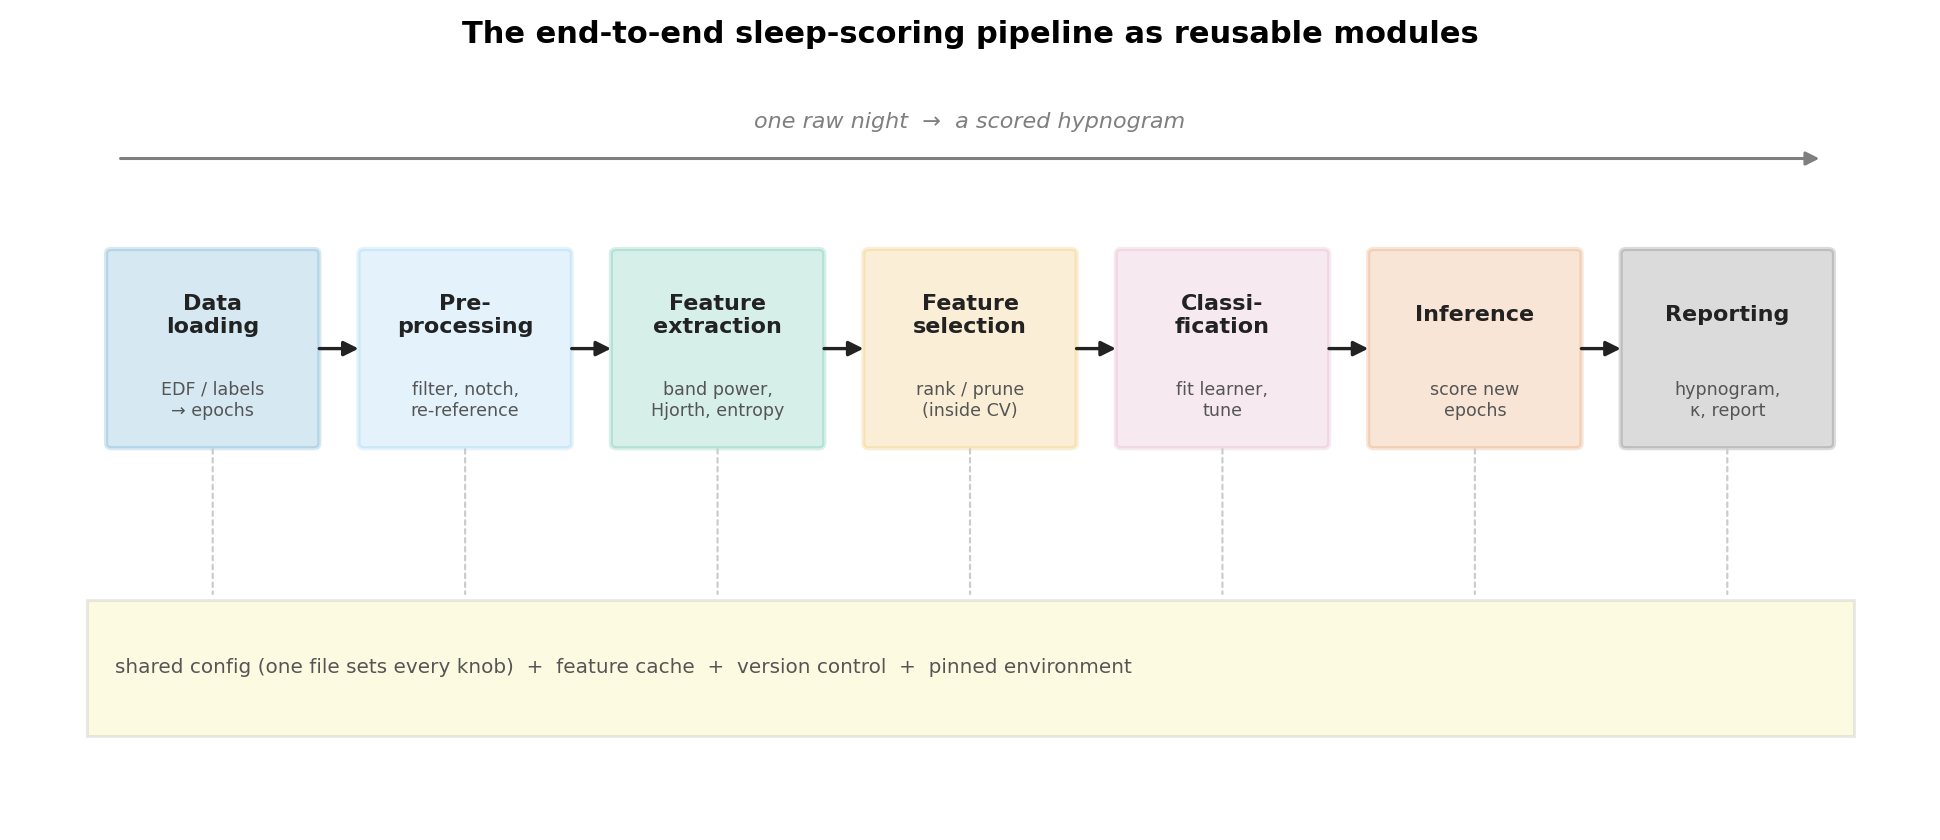

In [3]:
fig, ax = bs.newfig(w=9.8, h=4.3)
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")
ax.set_title("The end-to-end sleep-scoring pipeline as reusable modules",
             fontsize=11)

stages = [
    ("Data\nloading", "EDF / labels\n→ epochs", bs.C["blue"]),
    ("Pre-\nprocessing", "filter, notch,\nre-reference", bs.C["sky"]),
    ("Feature\nextraction", "band power,\nHjorth, entropy", bs.C["green"]),
    ("Feature\nselection", "rank / prune\n(inside CV)", bs.C["orange"]),
    ("Classi-\nfication", "fit learner,\ntune", bs.C["purple"]),
    ("Inference", "score new\nepochs", bs.C["red"]),
    ("Reporting", "hypnogram,\nκ, report", bs.C["black"]),
]
n = len(stages)
x0, x1 = 0.35, 9.65
span = x1 - x0
bw = span / n * 0.80          # box width
gap = span / n                # centre-to-centre spacing
ymid = 3.1
bh = 1.25

centres = []
for i, (title, sub, col) in enumerate(stages):
    xc = x0 + gap * (i + 0.5)
    centres.append(xc)
    box = FancyBboxPatch((xc - bw / 2, ymid - bh / 2), bw, bh,
                         boxstyle="round,pad=0.03", linewidth=1.5,
                         edgecolor=col, facecolor=col, alpha=0.16)
    ax.add_patch(box)
    ax.text(xc, ymid + 0.22, title, ha="center", va="center",
            fontsize=8.0, fontweight="bold", color=bs.C["black"])
    ax.text(xc, ymid - 0.34, sub, ha="center", va="center",
            fontsize=6.3, color="#555555")

# forward arrows between the boxes
for xa, xb in zip(centres[:-1], centres[1:]):
    ax.add_patch(FancyArrowPatch((xa + bw / 2, ymid), (xb - bw / 2, ymid),
                 arrowstyle="-|>", mutation_scale=11,
                 color=bs.C["black"], lw=1.2))

# data flow label along the top
ax.annotate("", xy=(9.5, 4.35), xytext=(0.5, 4.35),
            arrowprops=dict(arrowstyle="-|>", color=bs.C["grey"], lw=1.1))
ax.text(5.0, 4.55, "one raw night  →  a scored hypnogram",
        ha="center", fontsize=8, color=bs.C["grey"], style="italic")

# shared config + cache rail underneath (spans all modules)
rail = Rectangle((x0, 0.55), span, 0.9, fill=True, fc=bs.C["yellow"],
                 alpha=0.16, ec=bs.C["grey"], lw=1.1)
ax.add_patch(rail)
ax.text(x0 + 0.15, 1.0, "shared config (one file sets every knob)  +  "
        "feature cache  +  version control  +  pinned environment",
        fontsize=7.2, va="center", color="#555555")
for xc in centres:
    ax.add_patch(FancyArrowPatch((xc, ymid - bh / 2), (xc, 1.45),
                 arrowstyle="-", color=bs.C["lightgrey"], lw=0.8,
                 linestyle=(0, (2, 2))))

plt.tight_layout()
plt.show()

## 16.2  results

tuned-RF per-subject LOSO kappa: mean=0.614  range=[0.336, 0.725]


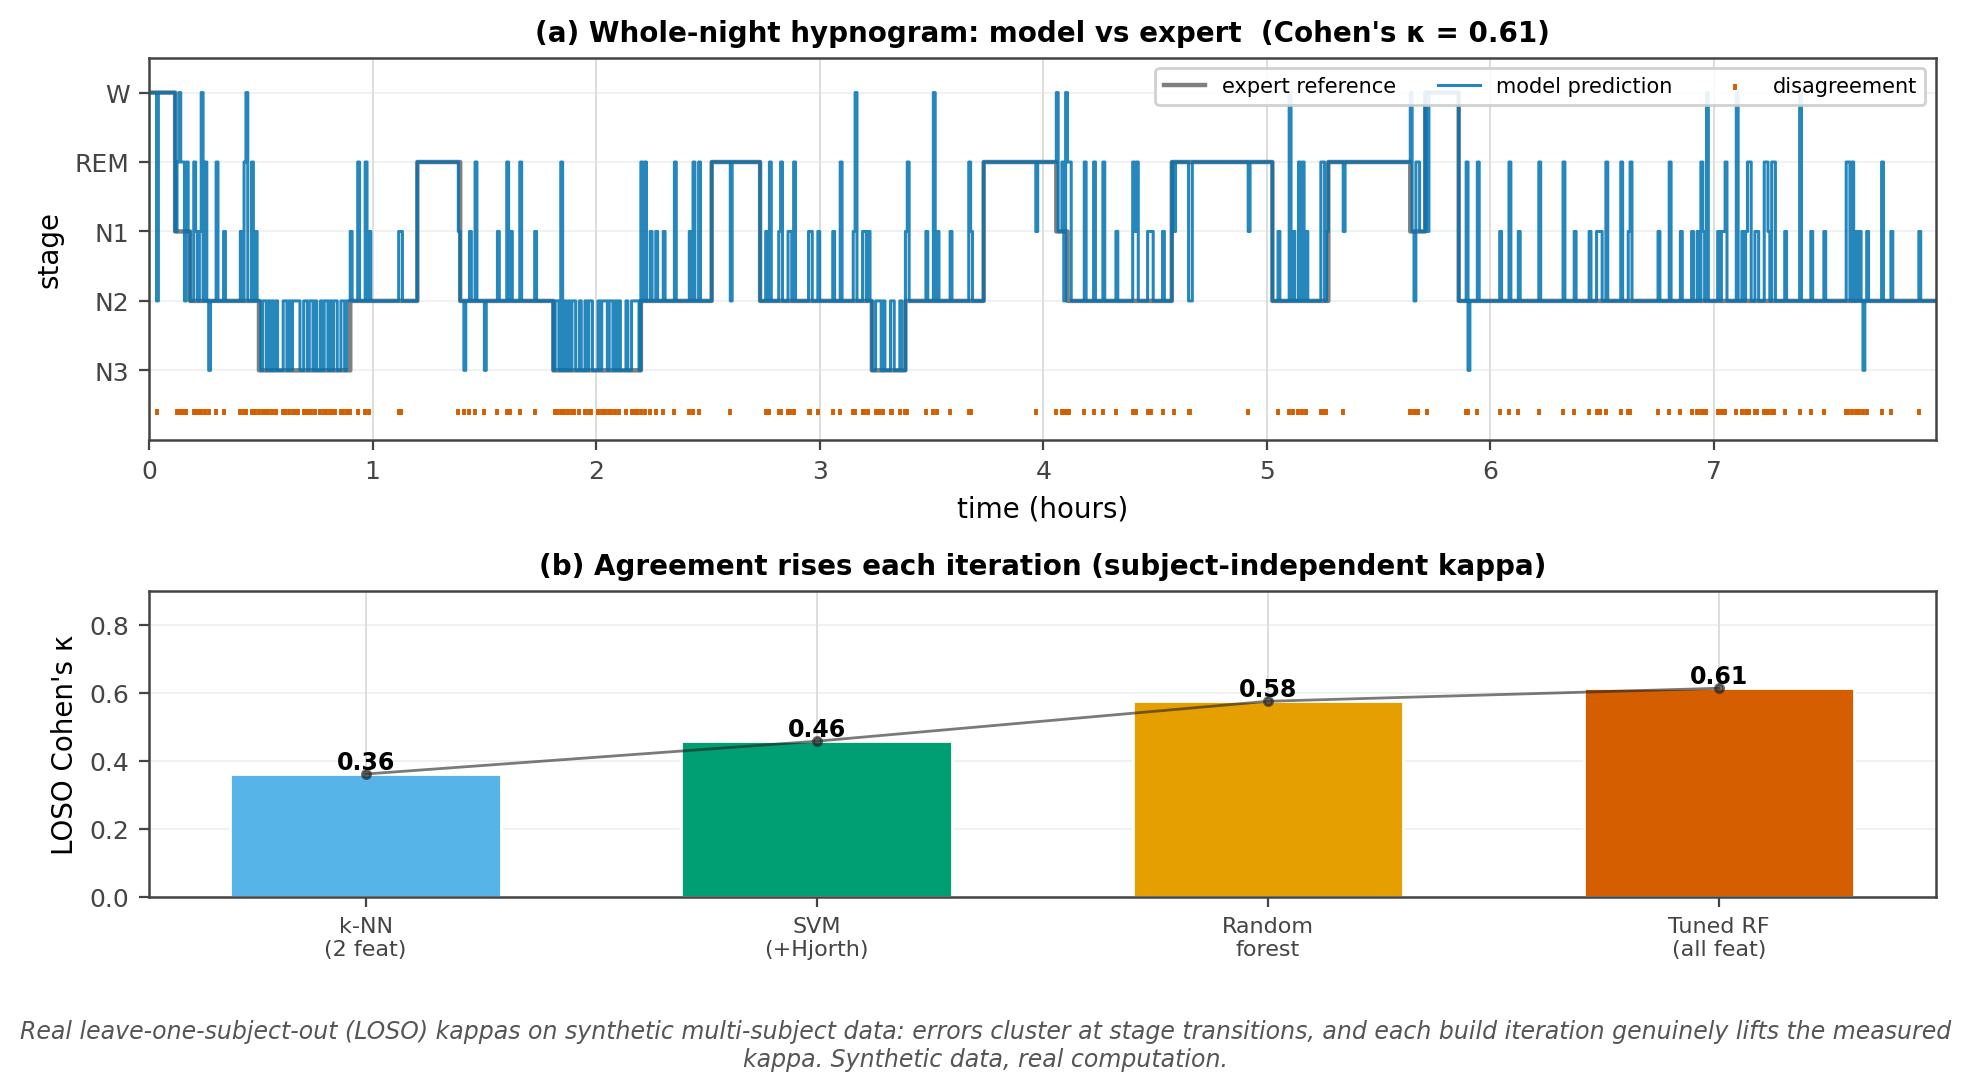

In [4]:
fig, axes = bs.newfig(w=9.8, h=5.0, nrows=2,
                      gridspec_kw={"height_ratios": [1.25, 1.0]})

# ---------------- (a) hypnogram: predicted vs reference ----------------
axA = axes[0]
ref, pred, kappas, tuned_per_subject, _y_all, _pred_all = _real_ladder()  # REAL training + LOSO predictions
print(f"tuned-RF per-subject LOSO kappa: mean={np.mean(tuned_per_subject):.3f}  "
      f"range=[{min(tuned_per_subject):.3f}, {max(tuned_per_subject):.3f}]")
hours = np.arange(len(ref)) * 30.0 / 3600.0    # epoch index -> hours

axA.step(hours, ref, where="post", color=bs.C["grey"], lw=1.6,
         label="expert reference")
axA.step(hours, pred, where="post", color=bs.C["blue"], lw=1.1,
         alpha=0.85, label="model prediction")
# mark disagreements
dis = np.where(ref != pred)[0]
axA.scatter(hours[dis], np.full(len(dis), -0.6), s=6, color=bs.C["red"],
            marker="|", label="disagreement")

axA.set_yticks(range(len(STAGE_ORDER)))
axA.set_yticklabels(STAGE_ORDER)
axA.set_ylim(-1.0, len(STAGE_ORDER) - 0.5)
axA.set_xlim(0, hours[-1])
axA.set_xlabel("time (hours)")
axA.set_ylabel("stage")
k_night = _cohen_kappa(ref, pred, len(STAGE_ORDER))
axA.set_title(f"(a) Whole-night hypnogram: model vs expert  "
              f"(Cohen's κ = {k_night:.2f})", fontsize=10)
axA.legend(loc="upper right", fontsize=7.5, ncol=3)
axA.grid(True, axis="y", alpha=0.4)

# ---------------- (b) kappa rising over iterations ----------------
axB = axes[1]
iters = ["k-NN\n(2 feat)", "SVM\n(+Hjorth)", "Random\nforest",
         "Tuned RF\n(all feat)"]
# kappas are REAL, from _real_ladder() above (true leave-one-subject-out)
cols = [bs.C["sky"], bs.C["green"], bs.C["orange"], bs.C["red"]]
xp = np.arange(len(iters))
bars = axB.bar(xp, kappas, width=0.6, color=cols, edgecolor="white")
for x, v in zip(xp, kappas):
    axB.text(x, v + 0.015, f"{v:.2f}", ha="center", fontsize=8.5,
             fontweight="bold")
# a dashed guide showing the upward march
axB.plot(xp, kappas, color=bs.C["black"], lw=1.0, marker="o",
         markersize=3, alpha=0.6)
axB.set_xticks(xp)
axB.set_xticklabels(iters, fontsize=8)
axB.set_ylabel("LOSO Cohen's κ")
axB.set_ylim(0, max(0.9, 1.1 * max(kappas)))
axB.set_title("(b) Agreement rises each iteration "
              "(subject-independent kappa)", fontsize=10)
axB.grid(True, axis="y", alpha=0.4)

bs.takeaway(fig, "Real leave-one-subject-out (LOSO) kappas on synthetic multi-subject "
                 "data: errors cluster at stage transitions, and each build iteration "
                 "genuinely lifts the measured kappa. Synthetic data, real computation.", y=-0.03)
plt.tight_layout()
plt.show()

## 16.3  confusion

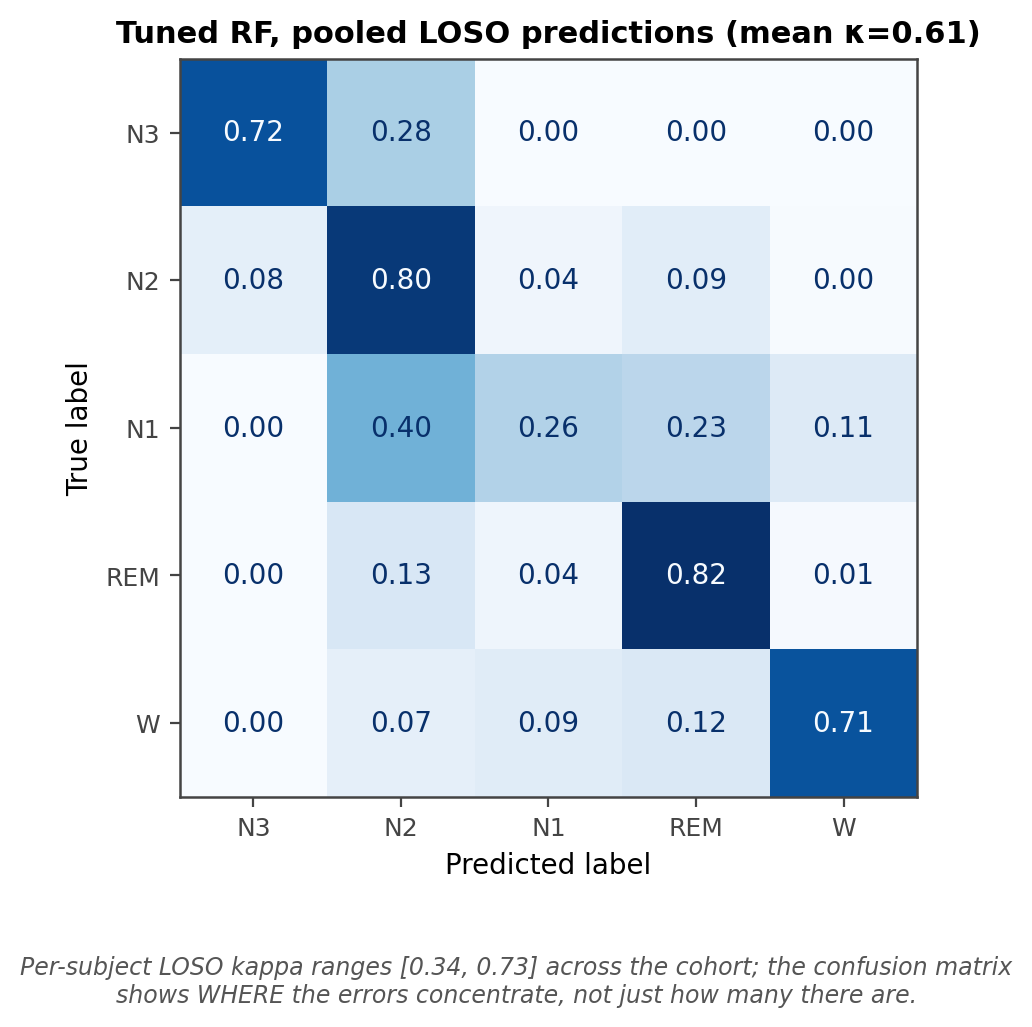

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
_ref0, _pred0, kappas, tuned_per_subject, y_all, pred_all = _real_ladder()
cm = confusion_matrix(y_all, pred_all, labels=range(len(STAGE_ORDER)), normalize="true")
fig, ax = bs.newfig(w=5.2, h=4.6)
ConfusionMatrixDisplay(cm, display_labels=STAGE_ORDER).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
ax.set_title(f"Tuned RF, pooled LOSO predictions (mean κ={np.mean(tuned_per_subject):.2f})")
ax.grid(False)
bs.takeaway(fig, "Per-subject LOSO kappa ranges "
                 f"[{min(tuned_per_subject):.2f}, {max(tuned_per_subject):.2f}] across the "
                 "cohort; the confusion matrix shows WHERE the errors concentrate, not just "
                 "how many there are.", y=-0.05)
plt.tight_layout()
plt.show()

## 16.4  agreement

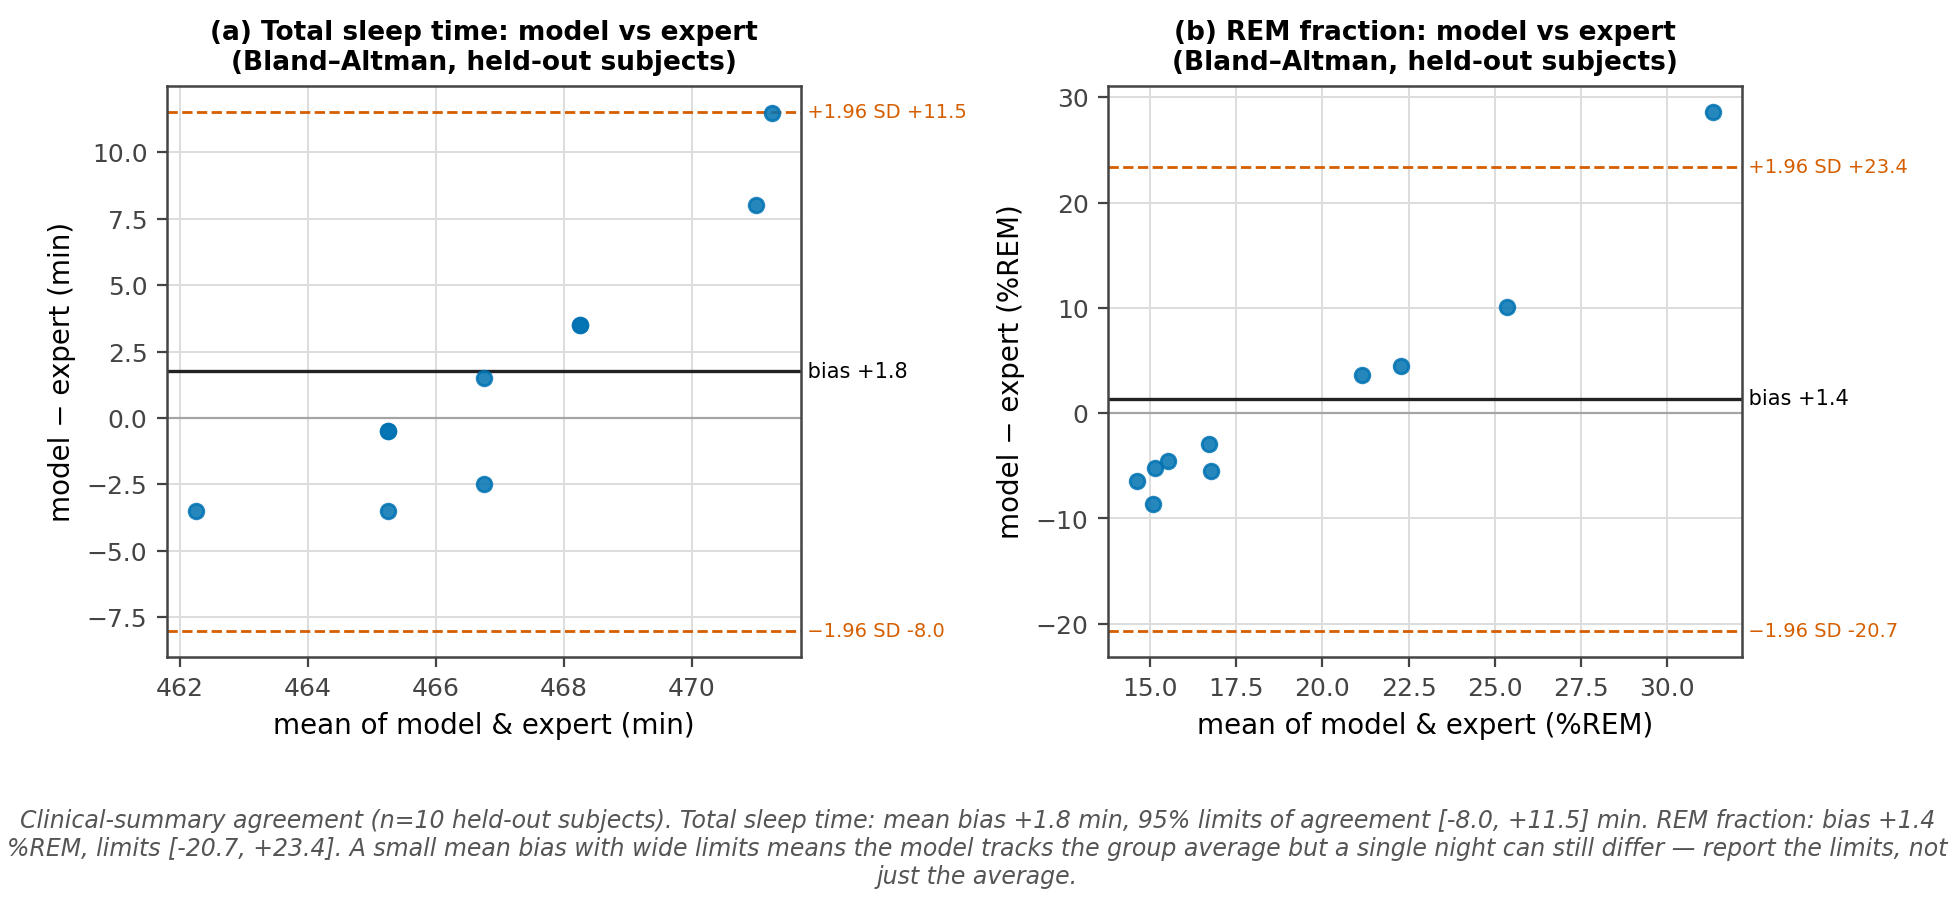

In [6]:
d = _agreement_data()
fig, axes = bs.newfig(w=9.6, h=3.9, nrows=1, ncols=2)

b_tst, lo_tst, hi_tst = _bland_altman(axes[0], d["tst_true"], d["tst_pred"], "min")
axes[0].set_title("(a) Total sleep time: model vs expert\n(Bland–Altman, held-out subjects)",
                  fontsize=9.5)

b_rem, lo_rem, hi_rem = _bland_altman(axes[1], d["rem_true"], d["rem_pred"], "%REM")
axes[1].set_title("(b) REM fraction: model vs expert\n(Bland–Altman, held-out subjects)",
                  fontsize=9.5)

# A short, honest written report — the number a clinician reads, with its limits.
bs.takeaway(fig, f"Clinical-summary agreement (n={len(d['subs'])} held-out subjects). "
                 f"Total sleep time: mean bias {b_tst:+.1f} min, 95% limits of agreement "
                 f"[{lo_tst:+.1f}, {hi_tst:+.1f}] min. REM fraction: bias {b_rem:+.1f} %REM, "
                 f"limits [{lo_rem:+.1f}, {hi_rem:+.1f}]. A small mean bias with wide limits "
                 "means the model tracks the group average but a single night can still differ "
                 "— report the limits, not just the average.", y=-0.05)
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above and the numbers below *exactly* — the cell below **asserts** them with `expect_close`, so a broken environment is flagged rather than failing silently.

In [7]:
from bsp.metrics import (alias_frequency, quantization_snr_db, sqrtN_gain_db,
                         snr_db, cohens_kappa, macro_f1)
from bsp.notebook_checks import expect_close, expected_output_table
from IPython.display import Markdown, display
from bsp import sleep_pipeline as sp
# 'medium' difficulty = realistic (not trivially separable); see docs/SYNTHETIC_CURRICULUM.md
_nights = sp.cohort(n_subjects=4, n_epochs=60, seed=0, difficulty='medium')
_X, _y, _g, _ = sp.feature_table(_nights)
_rep = sp.loso_evaluate(_X, _y, _g)
print('LOSO report:', {k: _rep[k] for k in ('accuracy','cohens_kappa','macro_f1')})
_rows = []
_rows.append(expect_close("capstone LOSO Cohen's kappa (medium — interval check)", _rep['cohens_kappa'], (0.45, 0.85), 0.0, 'range'))
_rows.append(expect_close('capstone macro-F1 (medium — interval check)', _rep['macro_f1'], (0.6, 0.9), 0.0, 'range'))
display(Markdown(expected_output_table(_rows)))

LOSO report: {'accuracy': 0.683, 'cohens_kappa': 0.596, 'macro_f1': 0.673}
[PASS] capstone LOSO Cohen's kappa (medium — interval check): got 0.596, expected [0.45, 0.85] (range)
[PASS] capstone macro-F1 (medium — interval check): got 0.673, expected [0.6, 0.9] (range)


| Quantity | Got | Expected | Status |
|---|---:|---:|:--:|
| capstone LOSO Cohen's kappa (medium — interval check) | 0.596 | [0.45, 0.85] | ✅ |
| capstone macro-F1 (medium — interval check) | 0.673 | [0.6, 0.9] | ✅ |

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> Chain the module scripts; save `predictions.csv`, `metrics`.

## Leakage-safety checklist

Any ML step in this notebook must obey:

- no scaling or feature selection **before** the split;
- no epoch-level random split when claiming new-subject generalisation (use LOSO / GroupKFold);
- every reported metric states its split unit (epoch, subject, night);
- synthetic performance is labelled *illustrative*, never clinical.

In [8]:
from bsp.notebook_checks import assert_no_subject_leak
# Example guard used throughout the pipeline notebooks:
# assert_no_subject_leak(groups[train_idx], groups[test_idx])

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Run the full mini-pipeline and produce a hypnogram + report paragraph.

<details><summary>💡 Hint &amp; what you should see</summary>

On 'medium' difficulty expect **κ ≈ 0.45–0.85** (not perfect — that is realistic). The hypnogram should track the true stages with N1 errors. Report κ / macro-F1 **with the split unit**.

</details>

**2.** Show the LOSO kappa rising across successive iterations.

<details><summary>💡 Hint &amp; what you should see</summary>

baseline → better features → tuned model should raise κ roughly monotonically; **each gain must be validated inside folds**. Plot κ vs iteration to make the improvement legible.

</details>

**3.** Read the Bland–Altman agreement figure: report the total-sleep-time bias and its 95% limits of agreement, and say why a small mean bias with wide limits still matters for a single night.

<details><summary>💡 Hint &amp; what you should see</summary>

The Bland–Altman plot shows model − expert against their mean: read the **mean bias** (systematic offset) and the **95% limits of agreement** (bias ± 1.96·SD). A small bias with wide limits means the group average agrees but a single night can still differ — report the limits, not just the average.

</details>

**4.** Build a simple quality-control detector (amplitude / flatline / clipping threshold) and score its precision & recall against the generator's known artifact masks in `night['artifacts']` — real data never hands you the ground truth, but the synthetic curriculum does.

<details><summary>💡 Hint &amp; what you should see</summary>

Threshold amplitude/flatline/clipping, then compare your flags to `night['artifacts']` (the ground-truth masks). Precision/recall quantify your detector — a luxury real data never gives you.

</details>

In [9]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch16_figures.py`.*